In [1]:
from pathlib import Path

import json, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, platform

# 한글 폰트 설정

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

In [2]:
# JSON 폴더 경로
JSON_DIR = Path("../data/labeled/annotations")

json_files = list(JSON_DIR.glob("*.json"))

print("JSON 파일 수 : ", len(json_files))

JSON 파일 수 :  907


In [3]:
# 클래스 정보 수집

labels = []

for json_file in json_files:
    with open(json_file, "r", encoding='utf-8') as f:
        data = json.load(f)

    for shape in data["shapes"]:
        labels.append(shape["label"])

print("총 객체 수 : ", len(labels))

총 객체 수 :  2065


In [4]:
# 클래스 분포 확인
label_series = pd.Series(labels)

label_counts = (label_series.value_counts())

label_counts

user_character    1070
user_id            994
eye                  1
Name: count, dtype: int64

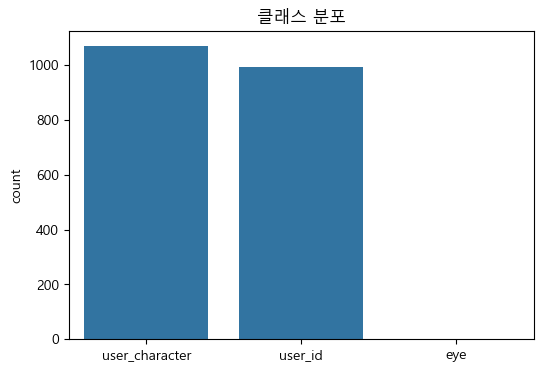

In [5]:
# 클래스 분포 시각화

plt.figure(figsize=(6,4))

sns.countplot(x=labels)

plt.title("클래스 분포")

plt.show()

In [6]:
# 이미지 별 객체 수 분석

object_counts = []

for json_file in json_files:
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    object_counts.append(len(data["shapes"]))

print("평균 객체 수 : ", round(sum(object_counts) / len(object_counts), 2))

평균 객체 수 :  2.28


In [7]:
# 객체 수 분포 확인
pd.Series(object_counts).value_counts().sort_index()

1     191
2     560
3      36
4      55
5      23
6      16
7       8
8      12
9       2
10      2
12      1
13      1
Name: count, dtype: int64

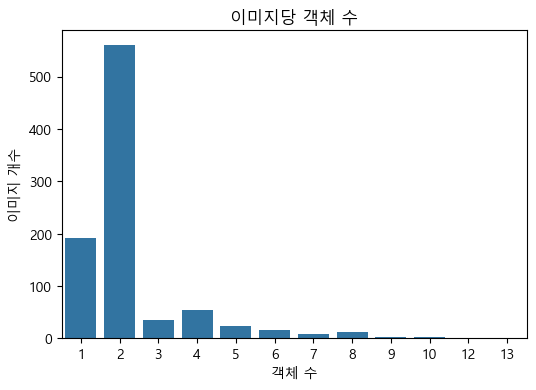

In [8]:
# 객체 수 분포 시각화 

plt.figure(figsize=(6,4))

sns.countplot(x=object_counts)

plt.title("이미지당 객체 수")
plt.xlabel("객체 수")
plt.ylabel("이미지 개수")
plt.show()

In [32]:
# Bounding Box 정보 수집

bbox_data = []

for json_file in json_files:

    with open(json_file, "r", encoding='utf-8') as f:
        data = json.load(f)

    for shape in data["shapes"]:
        
        label = shape["label"]
        # eye 제외
        if label == "eye":
            continue
        
        points = shape["points"]

        x1, y1 = points[0]
        x2, y2 = points[1]

        width = abs(x2 - x1)
        height = abs(y2 - y1)

        area = width * height

        bbox_data.append([label, width, height, area])


In [33]:
bbox_df = pd.DataFrame(bbox_data, columns=["label", "width","height", "area"])

bbox_df.head()

,label,width,height,area
0,user_character,191.623037,164.397906,31502.425920
1,user_id,72.712418,24.346405,1770.286001
2,user_character,102.334630,226.070039,23134.793865
3,user_id,67.507418,20.919881,1412.247180
4,user_character,105.235602,234.554974,24683.533894


In [34]:
# 클래스 별 통계 확인
bbox_df.groupby("label")[["width", "height", "area"]].describe().T

label         user_character      user_id
width  count     1070.000000   994.000000
       mean       102.077718    77.919857
       std         40.028641    25.581823
       min         36.764706    23.129252
       25%         73.565442    60.276425
       50%         92.243523    77.196671
       75%        121.097989    92.414383
       max        284.931507   180.952381
height count     1070.000000   994.000000
       mean       184.782244    24.071591
       std         42.639152     3.932885
       min         63.445378    11.986063
       25%        154.559970    21.556913
       50%        180.921908    23.692810
       75%        215.194304    25.993506
       max        335.029354    41.487280
area   count     1070.000000   994.000000
       mean     19309.178278  1908.630737
       std      10001.753284   822.185560
       min       2404.915686   365.033088
       25%      12312.778057  1339.103864
       50%      16671.020027  1804.144279
       75%      23862.399109  2313.010644
       max      74614.297586  6560.023897

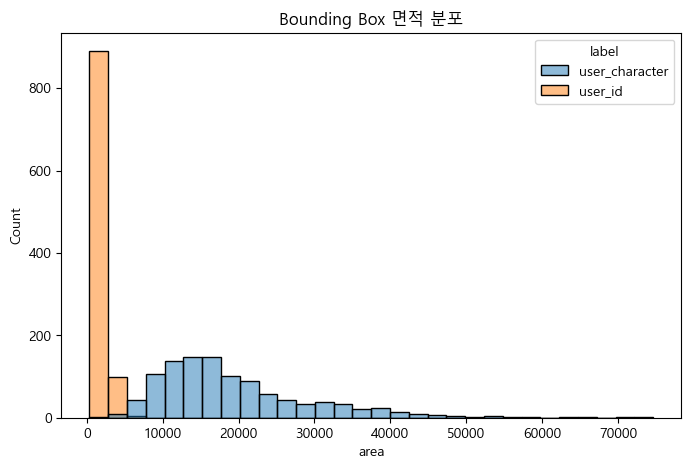

In [35]:
# Bounding Box 면적 분포

plt.figure(figsize=(8,5))
sns.histplot(data=bbox_df, x="area", hue="label", bins=30)
plt.title("Bounding Box 면적 분포")
plt.show()

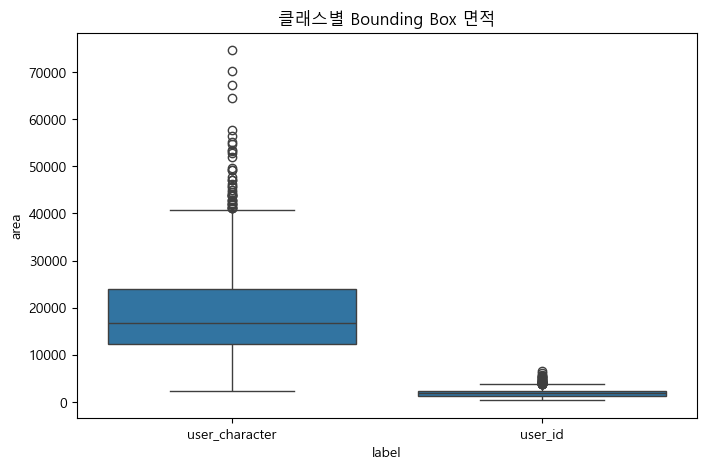

In [36]:
# 클래스별 Bounding Box 크기 비교

plt.figure(figsize=(8,5))

sns.boxplot(data=bbox_df, x="label", y="area")

plt.title("클래스별 Bounding Box 면적")

plt.show()

In [55]:
# Bounding Box 중심 좌표 수집

position_data = []

for json_file in json_files:
    
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for shape in data["shapes"]:

        label = shape["label"]
        if label == "eye":
            continue
        points = shape["points"]

        x1, y1 = shape["points"][0]
        x2, y2 = shape["points"][1]

        center_x = (x1 + x2) / 2

        center_y = (y1 + y2) / 2

        position_data.append([label, center_x, center_y])


In [56]:
position_df = pd.DataFrame(position_data, columns=[["label", "center_x", "center_y"]])

position_df.head()

,label,center_x,center_y
0,user_character,657.989529,566.492147
1,user_id,715.575163,397.794118
2,user_character,627.431907,520.038911
3,user_id,635.979228,390.875371
4,user_character,800.136126,576.439791


In [57]:
# position_df 구조 확인
print(type(position_df))
print(position_df.shape)
print(position_df.head())

<class 'pandas.DataFrame'>
(2064, 3)
            label    center_x    center_y
0  user_character  657.989529  566.492147
1         user_id  715.575163  397.794118
2  user_character  627.431907  520.038911
3         user_id  635.979228  390.875371
4  user_character  800.136126  576.439791


In [58]:
print(position_df.columns)

MultiIndex([(   'label',),
            ('center_x',),
            ('center_y',)],
           )


In [59]:
print(position_df.dtypes)

label           str
center_x    float64
center_y    float64
dtype: object


In [60]:
# MultiIndex 제거

position_df.columns = [
    col[0]
    for col in position_df.columns
]

print(position_df.columns)

Index(['label', 'center_x', 'center_y'], dtype='str')


In [61]:
# 위치 정보 확인
position_df.describe()

,center_x,center_y
count,2064.000000,2064.000000
mean,808.859718,560.951429
std,375.138444,126.352469
min,20.028011,73.569024
25%,619.006637,477.074336
50%,796.199591,555.470783
75%,970.866928,642.501012
max,2750.938478,1026.718162


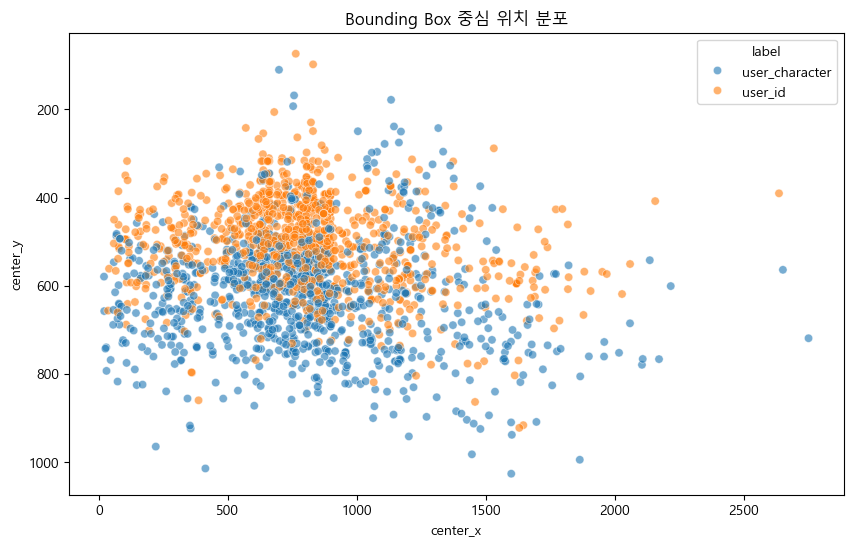

In [62]:
# 객체 위치 산점도

plt.figure(figsize=(10,6))

sns.scatterplot(data=position_df, x="center_x", y="center_y",
                hue="label", alpha=0.6)

plt.title("Bounding Box 중심 위치 분포")
plt.gca().invert_yaxis()
plt.show()

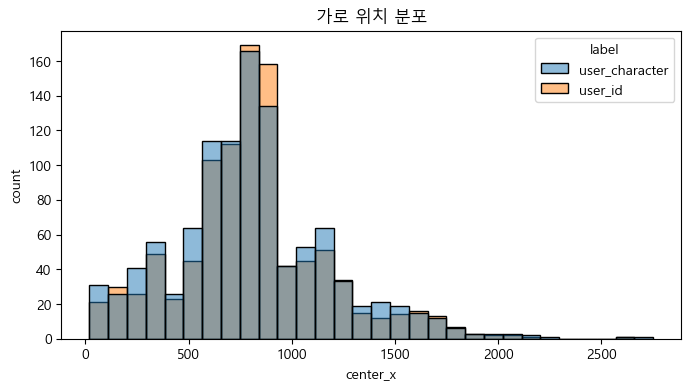

In [63]:
# 가로 위치 분포

plt.figure(figsize=(8, 4))

sns.histplot(data=position_df, x="center_x", hue="label", bins=30)

plt.title("가로 위치 분포")
plt.xlabel("center_x")
plt.ylabel("count")

plt.show()

x축 : 객체 중심의 가로 위치
y축 : 해당 위치에 등장한 객체 수

center_x = 0
→ 화면 맨 왼쪽

center_x = 1400
→ 화면 중앙

center_x = 2800
→ 화면 맨 오른쪽

---

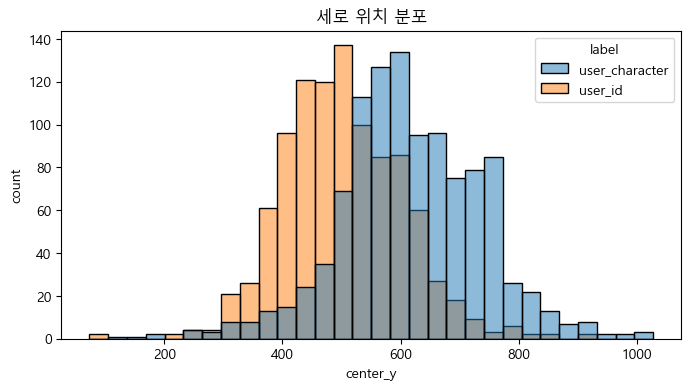

In [64]:
# 세로 위치 분포

plt.figure(figsize=(8, 4))

sns.histplot(data=position_df, x="center_y", hue="label", bins=30)

plt.title("세로 위치 분포")
plt.xlabel("center_y")
plt.ylabel("count")

plt.show()

x축 : 객체 중심의 세로 위치
y축 : 해당 위치에 등장한 객체 수

y = 0
→ 화면 위쪽

y = 900
→ 화면 아래쪽

---

```text
Bounding Box 위치 분포 분석 결과 user_character와 user_id는 
화면 중앙 영역에 주로 분포하는 것으로 확인되었다.

그러나 일부 객체는 화면 좌측 및 우측 가장자리에도 존재하여 
다양한 위치 정보를 포함하고 있는 것으로 나타났다.

또한 user_id는 user_character 상단에 위치하는 
게임 UI 특성이 데이터에 반영된 것으로 확인되었다.
```

In [65]:
import cv2
import random

In [66]:
# 이미지 / JSON 경로
IMAGE_DIR = Path("../data/labeled/images")
JSON_DIR = Path("../data/labeled/annotations")

In [67]:
COLOR_MAP = {
    "user_character" : (0, 255, 0), # 초록
    "user_id" : (255, 0, 0)         # 파랑
}

In [68]:
# 랜덤 이미지 선택
json_file = random.choice(list(JSON_DIR.glob("*.json")))

print(json_file.name)

ScreenShot2024_0315_071444471.json


In [69]:
# JSON 읽기

with open(json_file, "r", encoding="utf-8") as f:

    data = json.load(f)

data["imagePath"]

'ScreenShot2024_0315_071444471.jpg'

In [70]:
# 이미지 불러오기

image_path = (IMAGE_DIR / data["imagePath"])

img = cv2.imread(str(image_path))

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(img.shape)

(900, 1772, 3)


In [71]:
# Bounding Box 그리기

for shape in data["shapes"]:

    label = shape["label"]
    x1, y1 = map(int, shape["points"][0])
    x2, y2 = map(int, shape["points"][1])

    color = COLOR_MAP[label]

    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    cv2.putText(img, label, (x1, y1 - 10), 
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, color, 2)

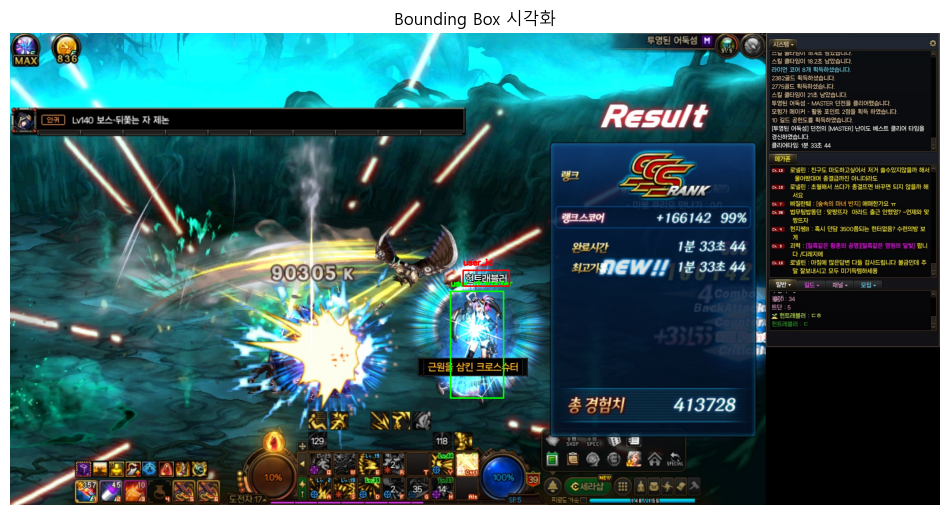

In [72]:
# 시각화

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.title("Bounding Box 시각화")
plt.show()

라벨링된 이미지 + 매칭되는 JSON 를 좌표로 특정하여 Bounding Box로 표현한 것임